In [1]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuración visual
sns.set_theme(style="whitegrid")

# ==========================================
# 2. CARGAR Y EXPLORAR DATOS
# ==========================================
# Cargar datos desde la carpeta raw
df = pd.read_csv('../data/raw/Customer Churn.csv')

print("--- DIMENSIONES DEL DATASET ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("--- PRIMERAS 5 FILAS ---")
display(df.head())

print("--- INFORMACIÓN DEL DATASET ---")
df.info()

--- DIMENSIONES DEL DATASET ---
Filas: 3150, Columnas: 14

--- PRIMERAS 5 FILAS ---


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


--- INFORMACIÓN DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: 


--- VALORES NULOS POR COLUMNA ---
Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64


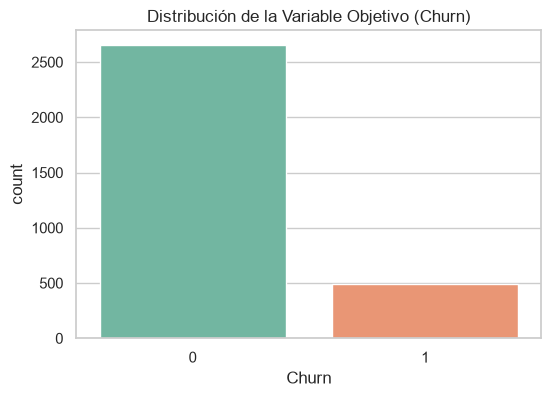

Proporción de Clases (%) :
Churn
0    84.285714
1    15.714286
Name: proportion, dtype: float64


In [4]:
# 3. ANÁLISIS EXPLORATORIO (EDA)
# ==========================================
print("\n--- VALORES NULOS POR COLUMNA ---")
print(df.isnull().sum())

# Distribución de la Variable Objetivo (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribución de la Variable Objetivo (Churn)')
plt.show()

print("Proporción de Clases (%) :")
print(df['Churn'].value_counts(normalize=True) * 100)

# ==========================================

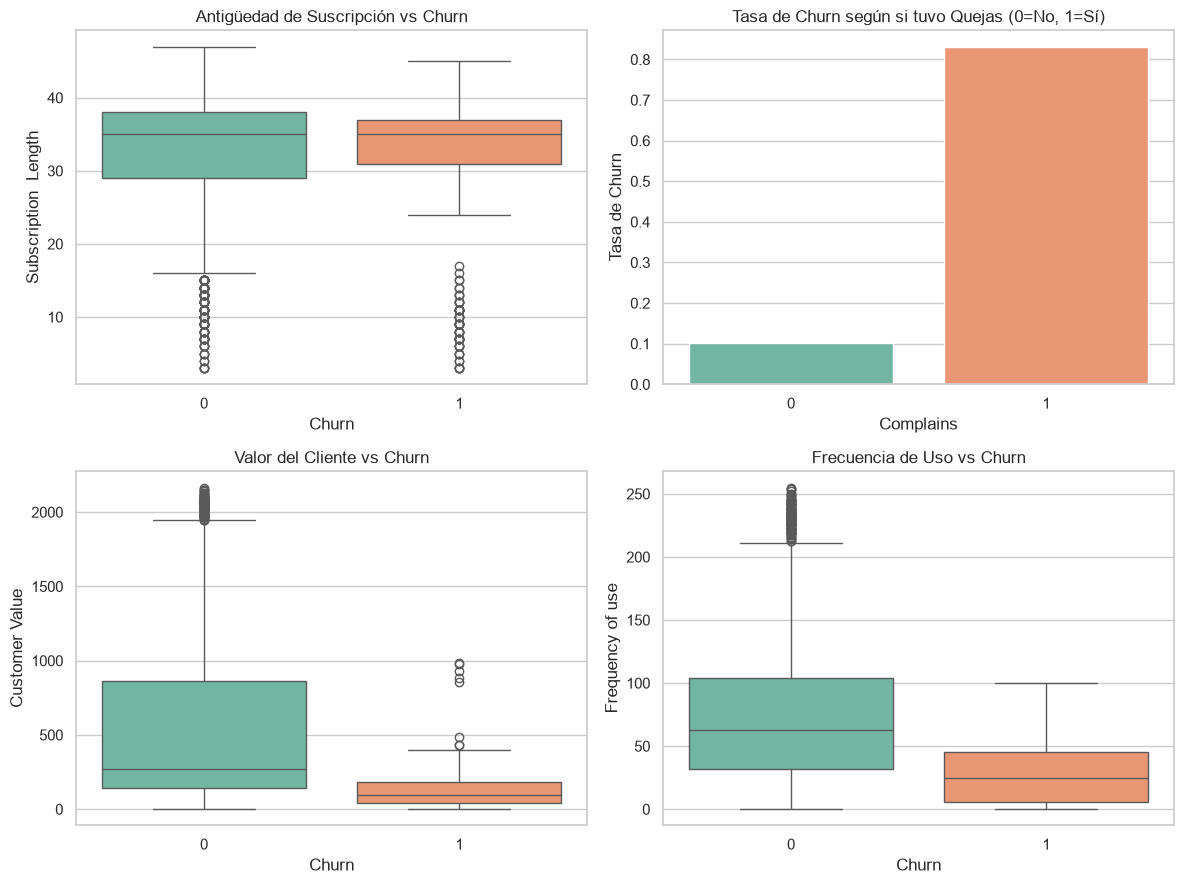

--- Tasa de Churn por presencia de Quejas ---
   Complains     Churn
0          0  0.101409
1          1  0.829876


In [6]:
# ==========================================
# 3.1 EDA BIVARIADO: INDICADORES CLAVE DE ABANDONO
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Antigüedad (Subscription Length) vs Churn
sns.boxplot(data=df, x='Churn', y='Subscription  Length', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Antigüedad de Suscripción vs Churn')

# Quejas vs Churn
complaints_churn = df.groupby('Complains')['Churn'].mean().reset_index()
sns.barplot(data=complaints_churn, x='Complains', y='Churn', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Tasa de Churn según si tuvo Quejas (0=No, 1=Sí)')
axes[0, 1].set_ylabel('Tasa de Churn')

# Valor del cliente vs Churn
sns.boxplot(data=df, x='Churn', y='Customer Value', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Valor del Cliente vs Churn')

# Frecuencia de uso vs Churn
sns.boxplot(data=df, x='Churn', y='Frequency of use', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Frecuencia de Uso vs Churn')

plt.tight_layout()
plt.show()

print("--- Tasa de Churn por presencia de Quejas ---")
print(complaints_churn)

In [5]:
# ==========================================
# 4. ESTRATEGIA DE PREPROCESAMIENTO
# ==========================================
print("""
--- ESTRATEGIA DEFINIDA PARA EL PREPROCESAMIENTO ---
1. Duplicados: El dataset tiene 300 filas duplicadas exactas (~9.5%).
   Se eliminarán antes de entrenar, para no sesgar al modelo.
2. Nulos: No hay nulos reales (confirmado con df.isnull().sum()).
3. Codificación: No se requiere, todas las variables ya son numéricas
   (incluyendo Churn, que ya viene como 0/1).
4. Escalado: Aplicar StandardScaler a variables con escalas muy distintas
   (Seconds of Use, Customer Value, Charge Amount) para algoritmos
   sensibles a la escala (ej. Regresión Logística).
5. Balanceo: Considerar SMOTE o class_weights debido al desbalanceo
   de la variable objetivo (revisar proporción real abajo).
""")


--- ESTRATEGIA DEFINIDA PARA EL PREPROCESAMIENTO ---
1. Duplicados: El dataset tiene 300 filas duplicadas exactas (~9.5%).
   Se eliminarán antes de entrenar, para no sesgar al modelo.
2. Nulos: No hay nulos reales (confirmado con df.isnull().sum()).
3. Codificación: No se requiere, todas las variables ya son numéricas
   (incluyendo Churn, que ya viene como 0/1).
4. Escalado: Aplicar StandardScaler a variables con escalas muy distintas
   (Seconds of Use, Customer Value, Charge Amount) para algoritmos
   sensibles a la escala (ej. Regresión Logística).
5. Balanceo: Considerar SMOTE o class_weights debido al desbalanceo
   de la variable objetivo (revisar proporción real abajo).



In [7]:
# ==========================================
# 4.1 TRATAMIENTO DE DUPLICADOS
# ==========================================
print(f"Filas totales antes: {df.shape[0]}")
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Filas totales después de eliminar duplicados: {df.shape[0]}")

print("\nProporción de clases después de eliminar duplicados (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Filas totales antes: 3150
Filas duplicadas exactas: 300
Filas totales después de eliminar duplicados: 2850

Proporción de clases después de eliminar duplicados (%):
Churn
0    84.350877
1    15.649123
Name: proportion, dtype: float64


In [8]:
# 5. ESTABLECER BASELINE DE RENDIMIENTO
# ==========================================
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo baseline (predice la clase mayoritaria)
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

In [9]:
print("--- RESULTADOS DEL MODELO BASELINE (DUMMY CLASSIFIER) ---")
print(classification_report(y_test, y_pred_dummy, zero_division=0))
print(f"ROC-AUC Score Baseline: {roc_auc_score(y_test, dummy_clf.predict_proba(X_test)[:, 1]):.4f}")

--- RESULTADOS DEL MODELO BASELINE (DUMMY CLASSIFIER) ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       481
           1       0.00      0.00      0.00        89

    accuracy                           0.84       570
   macro avg       0.42      0.50      0.46       570
weighted avg       0.71      0.84      0.77       570

ROC-AUC Score Baseline: 0.5000


In [10]:
# ==========================================
# 6. CONFIGURAR MLFLOW EXPERIMENT TRACKING
# ==========================================
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("churn-prediction")

with mlflow.start_run(run_name="baseline-dummy-classifier"):
    mlflow.log_param("modelo", "DummyClassifier")
    mlflow.log_param("estrategia", "most_frequent")
    mlflow.log_param("filas_dataset", df.shape[0])
    mlflow.log_param("duplicados_eliminados", 300)

    mlflow.log_metric("accuracy", 0.84)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, dummy_clf.predict_proba(X_test)[:, 1]))

print("Run registrado en MLflow correctamente.")

2026/08/29 21:39:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/29 21:39:17 INFO mlflow.store.db.utils: Updating database tables
2026/08/29 21:39:18 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


Run registrado en MLflow correctamente.


In [11]:
# ==========================================
# 7. PREPARAR DATOS PARA MODELADO
# ==========================================
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (ajustado SOLO con train, para no filtrar información del test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE: balancear SOLO el set de entrenamiento (nunca el de test)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Tamaño train original: {X_train.shape[0]}")
print(f"Tamaño train balanceado con SMOTE: {X_train_bal.shape[0]}")
print(f"\nDistribución de clases después de SMOTE:")
print(y_train_bal.value_counts())

Tamaño train original: 2280
Tamaño train balanceado con SMOTE: 3846

Distribución de clases después de SMOTE:
Churn
1    1923
0    1923
Name: count, dtype: int64


In [14]:
# ==========================================
# 8. ENTRENAR MODELOS Y REGISTRAR EN MLFLOW
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

modelos = {
    "logistic_regression": LogisticRegression(random_state=42, max_iter=1000),
    "random_forest": RandomForestClassifier(random_state=42, n_estimators=100),
}

resultados = {}

for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=nombre):
        modelo.fit(X_train_bal, y_train_bal)
        y_pred = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

        acc = modelo.score(X_test_scaled, y_test)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        mlflow.log_param("modelo", nombre)
        mlflow.log_param("balanceo", "SMOTE")
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        resultados[nombre] = {"accuracy": acc, "f1_score": f1, "roc_auc": roc_auc}
        print(f"--- {nombre} ---")
        print(classification_report(y_test, y_pred, zero_division=0))
        print(f"ROC-AUC: {roc_auc:.4f}\n")

print("Resumen comparativo:")
for nombre, m in resultados.items():
    print(f"{nombre}: Accuracy={m['accuracy']:.3f} | F1={m['f1_score']:.3f} | ROC-AUC={m['roc_auc']:.3f}")

--- logistic_regression ---
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       481
           1       0.50      0.87      0.63        89

    accuracy                           0.84       570
   macro avg       0.74      0.85      0.77       570
weighted avg       0.90      0.84      0.86       570

ROC-AUC: 0.9248

--- random_forest ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       481
           1       0.86      0.88      0.87        89

    accuracy                           0.96       570
   macro avg       0.92      0.92      0.92       570
weighted avg       0.96      0.96      0.96       570

ROC-AUC: 0.9799

Resumen comparativo:
logistic_regression: Accuracy=0.844 | F1=0.634 | ROC-AUC=0.925
random_forest: Accuracy=0.958 | F1=0.867 | ROC-AUC=0.980


In [15]:
# ==========================================
# 9. REGISTRAR EL MEJOR MODELO (RANDOM FOREST) COMO @champion
# ==========================================
from mlflow.client import MlflowClient

with mlflow.start_run(run_name="random_forest_champion"):
    rf_final = RandomForestClassifier(random_state=42, n_estimators=100)
    rf_final.fit(X_train_bal, y_train_bal)

    y_pred = rf_final.predict(X_test_scaled)
    y_proba = rf_final.predict_proba(X_test_scaled)[:, 1]

    mlflow.log_param("modelo", "random_forest")
    mlflow.log_param("balanceo", "SMOTE")
    mlflow.log_metric("accuracy", rf_final.score(X_test_scaled, y_test))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_proba))

    mlflow.sklearn.log_model(
        rf_final,
        artifact_path="modelo",
        registered_model_name="churn-random-forest"
    )
    run_id = mlflow.active_run().info.run_id

client = MlflowClient()
latest_version = client.get_latest_versions("churn-random-forest")[0].version

client.set_registered_model_alias(
    name="churn-random-forest",
    alias="champion",
    version=latest_version
)

print(f"Modelo registrado: churn-random-forest, versión {latest_version}, alias '@champion'")

2026/08/29 22:10:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Modelo registrado: churn-random-forest, versión 1, alias '@champion'


Successfully registered model 'churn-random-forest'.
Created version '1' of model 'churn-random-forest'.


In [16]:
# ==========================================
# 8.1 VALIDACIÓN CRUZADA (CROSS-VALIDATION)
# ==========================================
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="random_forest_cross_validation"):
    rf_cv = RandomForestClassifier(random_state=42, n_estimators=100)

    # Cross-validation sobre el set de entrenamiento balanceado con SMOTE
    scores_f1 = cross_val_score(rf_cv, X_train_bal, y_train_bal, cv=cv, scoring='f1')
    scores_roc = cross_val_score(rf_cv, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')

    mlflow.log_param("modelo", "random_forest")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_metric("f1_cv_mean", scores_f1.mean())
    mlflow.log_metric("f1_cv_std", scores_f1.std())
    mlflow.log_metric("roc_auc_cv_mean", scores_roc.mean())
    mlflow.log_metric("roc_auc_cv_std", scores_roc.std())

    print(f"F1-Score por fold: {scores_f1.round(3)}")
    print(f"F1-Score promedio: {scores_f1.mean():.3f} (+/- {scores_f1.std():.3f})")
    print(f"\nROC-AUC por fold: {scores_roc.round(3)}")
    print(f"ROC-AUC promedio: {scores_roc.mean():.3f} (+/- {scores_roc.std():.3f})")

F1-Score por fold: [0.968 0.983 0.974 0.969 0.968]
F1-Score promedio: 0.972 (+/- 0.006)

ROC-AUC por fold: [0.992 0.998 0.995 0.995 0.991]
ROC-AUC promedio: 0.994 (+/- 0.003)
